# Model Measured S1P With scikit-rf

> Goal: use scikit-rf to load measured `.S1P` files, fit a compact equivalent circuit, and compare measured vs modeled $S_{11}$.

Circuit used: series $L$ plus shunt $R\parallel C$

$$Z_{in}(\omega)=j\omega L + \left(\frac{1}{R} + j\omega C\right)^{-1}, \quad \Gamma=\frac{Z_{in}-Z_0}{Z_{in}+Z_0}$$

In [7]:
from pathlib import Path
import re
import numpy as np
import matplotlib.pyplot as plt

try:
    import skrf as rf
except Exception as e:
    raise ImportError("Install scikit-rf first: pip install scikit-rf") from e

try:
    from scipy.optimize import least_squares
except Exception as e:
    raise ImportError("Install SciPy first: pip install scipy") from e

Z0 = 50.0

def nominal_r_from_name(path):
    m = re.search(r"(\d+)OHM", path.stem.upper())
    return float(m.group(1)) if m else 100.0

In [8]:
def zin_from_params(freq_hz, R, L, C):
    w = 2 * np.pi * freq_hz
    z_shunt = 1.0 / (1.0 / R + 1j * w * C)
    return 1j * w * L + z_shunt

def s11_from_params(freq_hz, R, L, C, z0=Z0):
    z = zin_from_params(freq_hz, R, L, C)
    return (z - z0) / (z + z0)

def fit_equiv_circuit(ntw, R_init=100.0):
    f = ntw.f
    z_meas = ntw.z[:, 0, 0]

    x0 = np.log([R_init, 1e-9, 1e-12])
    lb = np.log([1.0, 1e-12, 1e-15])
    ub = np.log([1e5, 1e-6, 1e-9])

    def residual(x):
        R, L, C = np.exp(x)
        z_fit = zin_from_params(f, R, L, C)
        e = z_fit - z_meas
        return np.hstack([e.real, e.imag])

    res = least_squares(residual, x0=x0, bounds=(lb, ub), max_nfev=5000)
    R, L, C = np.exp(res.x)
    s_fit = s11_from_params(f, R, L, C)
    rmse = np.sqrt(np.mean(np.abs(s_fit - ntw.s[:, 0, 0]) ** 2))
    return {"R": R, "L": L, "C": C, "s11_fit": s_fit, "rmse": rmse}

In [9]:
data_dir = Path("../data")
file_LNA = Path("../data/LNA12.S2P")

ntw = rf.Network(str(file_LNA))
out = fit_equiv_circuit(ntw, R_init=nominal_r_from_name(file_LNA))
LNA_result = {"ntw": ntw, **out}

print("Fit summary (using scikit-rf + least_squares):")
print(f"{'file':<14} {'R_fit(ohm)':>12} {'L_fit(nH)':>12} {'C_fit(pF)':>12} {'RMSE':>10}")
print(f"{file_LNA.name:<14} {LNA_result['R']:12.2f} {LNA_result['L']*1e9:12.3f} {LNA_result['C']*1e12:12.3f} {LNA_result['rmse']:10.4e}")

Fit summary (using scikit-rf + least_squares):
file             R_fit(ohm)    L_fit(nH)    C_fit(pF)       RMSE
LNA12.S2P           1985.69        0.001        8.826 1.1713e-01


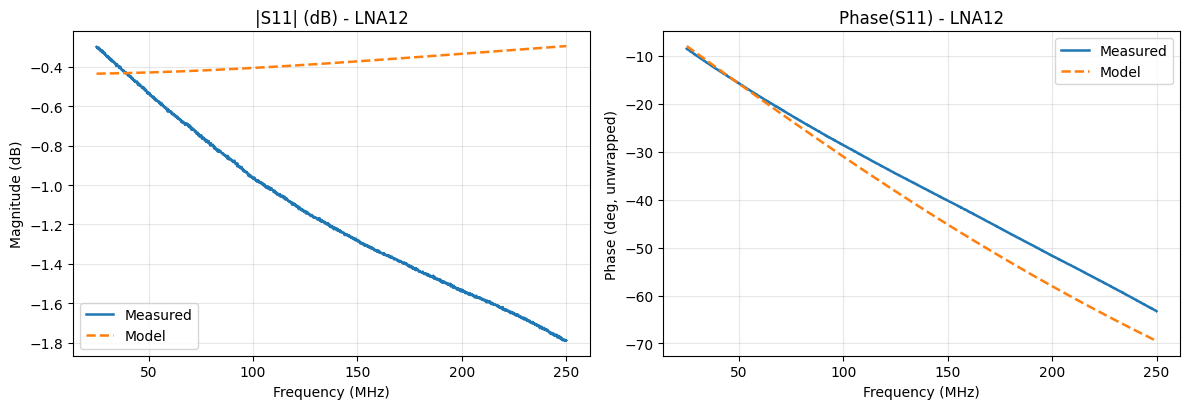

Fitted for LNA12: R=1985.69 ohm, L=0.001 nH, C=8.826 pF


In [10]:
example = 'LNA12' # change this to inspect another part
d = LNA_result
ntw = d["ntw"]

f_mhz = ntw.f / 1e6
s_meas = ntw.s[:, 0, 0]
s_fit = d["s11_fit"]

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))

ax[0].plot(f_mhz, 20*np.log10(np.abs(s_meas)), lw=1.8, label="Measured")
ax[0].plot(f_mhz, 20*np.log10(np.abs(s_fit)), "--", lw=1.8, label="Model")
ax[0].set_title(f"|S11| (dB) - {example}")
ax[0].set_xlabel("Frequency (MHz)")
ax[0].set_ylabel("Magnitude (dB)")
ax[0].grid(alpha=0.3)
ax[0].legend()

ax[1].plot(f_mhz, np.unwrap(np.angle(s_meas))*180/np.pi, lw=1.8, label="Measured")
ax[1].plot(f_mhz, np.unwrap(np.angle(s_fit))*180/np.pi, "--", lw=1.8, label="Model")
ax[1].set_title(f"Phase(S11) - {example}")
ax[1].set_xlabel("Frequency (MHz)")
ax[1].set_ylabel("Phase (deg, unwrapped)")
ax[1].grid(alpha=0.3)
ax[1].legend()

plt.tight_layout()
plt.show()

print(f"Fitted for {example}: R={d['R']:.2f} ohm, L={d['L']*1e9:.3f} nH, C={d['C']*1e12:.3f} pF")

## Simple Vector Fitting (LNA21 target)

This section uses scikit-rf `VectorFitting` to model the measured LNA S-parameters.
If `LNA21.S2P` is not found, it falls back to `LNA12.S2P`.

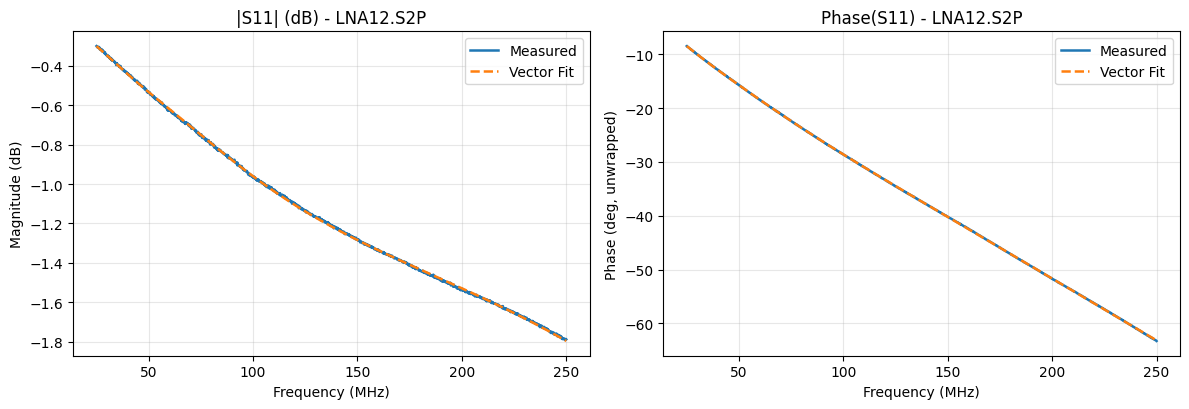

Vector fitting file: LNA12.S2P
RMSE(|complex S11|) = 6.8626e-04


In [13]:
# Choose LNA21 if available, otherwise use LNA12.
file_lna21 = Path("../data/LNA21.S2P")
file_lna12 = Path("../data/LNA12.S2P")
file_vf = file_lna21 if file_lna21.exists() else file_lna12

if not file_vf.exists():
    raise FileNotFoundError("Neither LNA21.S2P nor LNA12.S2P exists in ../data")

ntw_vf = rf.Network(str(file_vf))

from skrf.vectorFitting import VectorFitting
vf = VectorFitting(ntw_vf)
vf.vector_fit(
    n_poles_real=2,
    n_poles_cmplx=2,
    fit_constant=True,
    fit_proportional=False,
    parameter_type="s",
)

f_hz = ntw_vf.f
s11_meas = ntw_vf.s[:, 0, 0]

try:
    s11_vf = vf.get_model_response(0, 0, f_hz)
except TypeError:
    s11_vf = vf.get_model_response(0, 0, freqs=f_hz)

rmse_vf = np.sqrt(np.mean(np.abs(s11_vf - s11_meas) ** 2))
f_mhz = f_hz / 1e6

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))

ax[0].plot(f_mhz, 20*np.log10(np.abs(s11_meas)), lw=1.8, label="Measured")
ax[0].plot(f_mhz, 20*np.log10(np.abs(s11_vf)), "--", lw=1.8, label="Vector Fit")
ax[0].set_title(f"|S11| (dB) - {file_vf.name}")
ax[0].set_xlabel("Frequency (MHz)")
ax[0].set_ylabel("Magnitude (dB)")
ax[0].grid(alpha=0.3)
ax[0].legend()

ax[1].plot(f_mhz, np.unwrap(np.angle(s11_meas))*180/np.pi, lw=1.8, label="Measured")
ax[1].plot(f_mhz, np.unwrap(np.angle(s11_vf))*180/np.pi, "--", lw=1.8, label="Vector Fit")
ax[1].set_title(f"Phase(S11) - {file_vf.name}")
ax[1].set_xlabel("Frequency (MHz)")
ax[1].set_ylabel("Phase (deg, unwrapped)")
ax[1].grid(alpha=0.3)
ax[1].legend()

plt.tight_layout()
plt.show()

print(f"Vector fitting file: {file_vf.name}")
print(f"RMSE(|complex S11|) = {rmse_vf:.4e}")

## Equivalent Circuit From Vector Fit (Simple RLC Approximation)

Vector fitting gives a rational macromodel, not one unique physical circuit.
Here we fit a few simple 3-parameter RLC topologies to the vector-fitted response and pick the best RMSE.

Target file: LNA12.S2P

Simple RLC candidates fitted to vector-fit response:
model                                R(ohm)        L(nH)        C(pF)       RMSE
series R-L-C                          42.46        0.001        9.176 1.0868e-01
shunt C + series (R+L)                 1981     0.002509        8.769 1.1474e-01
series L + shunt (R||C)                1981        0.001        8.769 1.1474e-01

Selected equivalent circuit type: series R-L-C
R = 42.465 ohm
L = 0.001 nH
C = 9.1757 pF


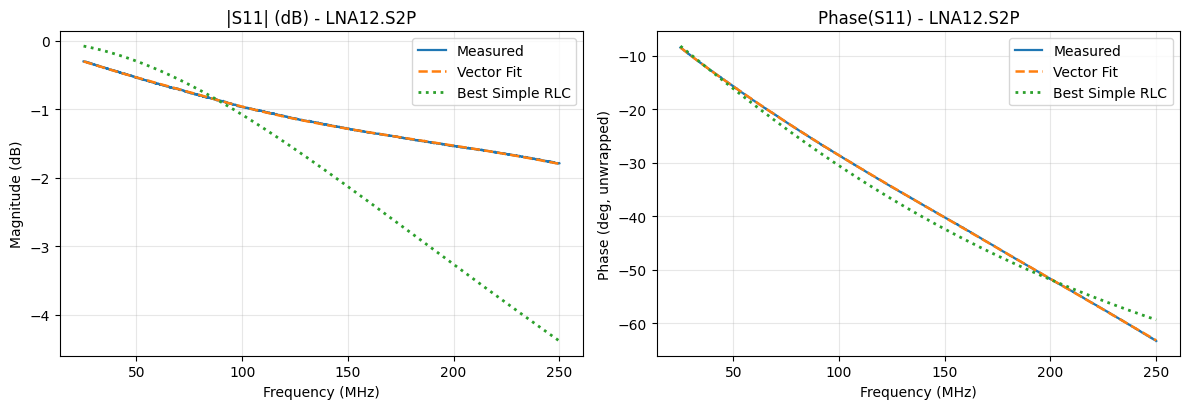

In [14]:
def z_from_s11(s11, z0=Z0):
    return z0 * (1 + s11) / (1 - s11)

def s11_from_z(z, z0=Z0):
    return (z - z0) / (z + z0)

def z_model(freq_hz, p, model_name):
    R, L, C = p
    w = 2 * np.pi * freq_hz
    jw = 1j * w
    eps = 1e-30
    if model_name == "series R-L-C":
        return R + jw * L + 1.0 / (jw * C + eps)
    if model_name == "series L + shunt (R||C)":
        return jw * L + 1.0 / (1.0 / R + jw * C)
    if model_name == "shunt C + series (R+L)":
        z_rl = R + jw * L
        return 1.0 / (jw * C + 1.0 / z_rl)
    raise ValueError(f"Unknown model: {model_name}")

def fit_simple_rlc_to_z(freq_hz, z_target, model_name):
    x0 = np.log([50.0, 1e-9, 1e-12])
    lb = np.log([1e-3, 1e-12, 1e-15])
    ub = np.log([1e6, 1e-5, 1e-8])

    def residual(x):
        p = np.exp(x)
        z_fit = z_model(freq_hz, p, model_name)
        e = z_fit - z_target
        return np.hstack([e.real, e.imag])

    res = least_squares(residual, x0=x0, bounds=(lb, ub), max_nfev=7000)
    p = np.exp(res.x)
    z_fit = z_model(freq_hz, p, model_name)
    s_fit = s11_from_z(z_fit)
    rmse = np.sqrt(np.mean(np.abs(s_fit - s11_from_z(z_target)) ** 2))
    return {"model": model_name, "R": p[0], "L": p[1], "C": p[2], "s11_fit": s_fit, "rmse": rmse}

# Use vector-fitted response as the target for circuit extraction.
z_vf = z_from_s11(s11_vf)
candidate_models = [
    "series R-L-C",
    "series L + shunt (R||C)",
    "shunt C + series (R+L)",
]

cands = [fit_simple_rlc_to_z(f_hz, z_vf, m) for m in candidate_models]
cands = sorted(cands, key=lambda d: d["rmse"] )
best = cands[0]

print(f"Target file: {file_vf.name}")
print("\nSimple RLC candidates fitted to vector-fit response:")
print(f"{'model':<30} {'R(ohm)':>12} {'L(nH)':>12} {'C(pF)':>12} {'RMSE':>10}")
for c in cands:
    print(f"{c['model']:<30} {c['R']:12.4g} {c['L']*1e9:12.4g} {c['C']*1e12:12.4g} {c['rmse']:10.4e}")

print("\nSelected equivalent circuit type:", best["model"])
print(f"R = {best['R']:.6g} ohm")
print(f"L = {best['L']*1e9:.6g} nH")
print(f"C = {best['C']*1e12:.6g} pF")

# Visual check: measured vs vector-fit vs extracted-RLC.
s_best = best["s11_fit"]
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))

ax[0].plot(f_mhz, 20*np.log10(np.abs(s11_meas)), lw=1.6, label="Measured")
ax[0].plot(f_mhz, 20*np.log10(np.abs(s11_vf)), "--", lw=1.8, label="Vector Fit")
ax[0].plot(f_mhz, 20*np.log10(np.abs(s_best)), ":", lw=2.0, label="Best Simple RLC")
ax[0].set_title(f"|S11| (dB) - {file_vf.name}")
ax[0].set_xlabel("Frequency (MHz)")
ax[0].set_ylabel("Magnitude (dB)")
ax[0].grid(alpha=0.3)
ax[0].legend()

ax[1].plot(f_mhz, np.unwrap(np.angle(s11_meas))*180/np.pi, lw=1.6, label="Measured")
ax[1].plot(f_mhz, np.unwrap(np.angle(s11_vf))*180/np.pi, "--", lw=1.8, label="Vector Fit")
ax[1].plot(f_mhz, np.unwrap(np.angle(s_best))*180/np.pi, ":", lw=2.0, label="Best Simple RLC")
ax[1].set_title(f"Phase(S11) - {file_vf.name}")
ax[1].set_xlabel("Frequency (MHz)")
ax[1].set_ylabel("Phase (deg, unwrapped)")
ax[1].grid(alpha=0.3)
ax[1].legend()

plt.tight_layout()
plt.show()

equiv_from_vf = best

## Smith Chart Comparison

This plot shows the measured trace and the fitted trace on a Smith chart.
Use it to check whether the fit matches the impedance trajectory, not just magnitude and phase.

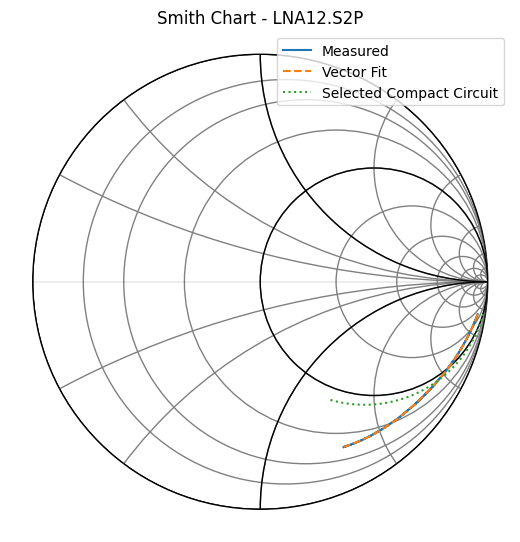

In [16]:
# Smith chart: measured vs vector fit vs extracted compact circuit.
vf_ntw = rf.Network(frequency=ntw_vf.frequency, s=s11_vf.reshape(-1, 1, 1), z0=Z0)
best_ntw = rf.Network(frequency=ntw_vf.frequency, s=s_best.reshape(-1, 1, 1), z0=Z0)

fig, ax = plt.subplots(figsize=(6.5, 6.5))
ntw_vf.plot_s_smith(m=0, n=0, ax=ax, label="Measured")
vf_ntw.plot_s_smith(m=0, n=0, ax=ax, label="Vector Fit", linestyle="--")
best_ntw.plot_s_smith(m=0, n=0, ax=ax, label="Selected Compact Circuit", linestyle=":")
ax.legend(loc="upper right")
ax.set_title(f"Smith Chart - {file_vf.name}")
plt.show()

## Minimal Workflow

1. Run cells 1 to 5 for the simple RLC equivalent-circuit fit and plot.
2. Run cells 6 and 7 for vector fitting on LNA data.
3. Run cells 8 and 9 to extract a best simple RLC type and parameters from the vector-fit model.
4. If you add `LNA21.S2P`, cell 7 will use it automatically; otherwise it uses `LNA12.S2P`.